
# Linear Regression: Complete Guide

---

## Supervised Learning - Evaluation Metrics

| Task | Metric Examples |
|------|-----------------|
| **Regression** | MAE, MSE, RMSE, R2, Adjusted R2 |
| **Classification** | Accuracy, Precision, Recall, F1, ROC-AUC, Log Loss |

---

## 1. Linear Regression Overview

### Simple Linear Regression

The goal is to find the best-fit line that minimizes the error between predicted and actual values.

$$y = \theta_0 + \theta_1 x$$

Where:
- $y$ = predicted value (dependent variable)
- $x$ = input feature (independent variable)
- $\theta_0$ = intercept (bias term)
- $\theta_1$ = slope (coefficient/weight)


In [10]:

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!



---

## 2. Data Loading

We will use the **Wine Quality Dataset** from UCI Machine Learning Repository.
- This dataset contains physicochemical properties of red wine samples
- Our target variable will be **quality** (a score between 0 and 10)


In [11]:

# Step 2: Load Real-World Dataset (Wine Quality Dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()


DATASET OVERVIEW
Shape: (1599, 12)
Number of samples: 1599
Number of features: 12

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [12]:

# Display basic info about the dataset
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()


Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Basic Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



---

## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the data better before building the model.


In [13]:

# Step 3: Exploratory Data Analysis - Data Quality Check
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nDuplicate rows:", df.duplicated().sum())


DATA QUALITY CHECK

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0

Duplicate rows: 240


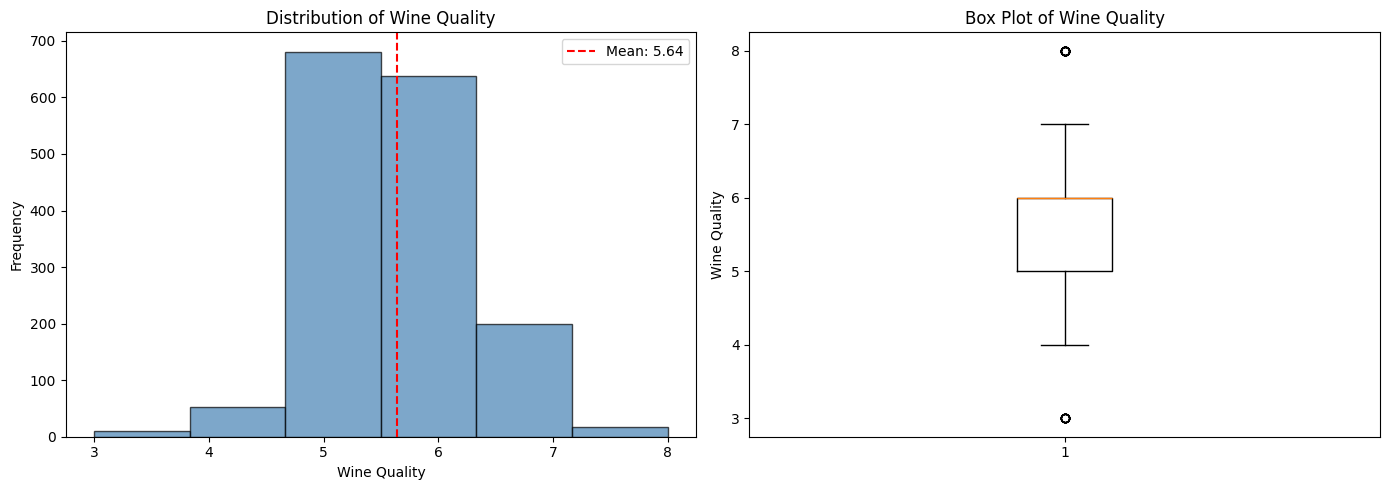


Target Variable Statistics:
Mean: 5.64
Median: 6.00
Std: 0.81
Min: 3
Max: 8


In [14]:

# Step 4: Exploratory Data Analysis - Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['quality'], bins=6, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Wine Quality')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Wine Quality')
axes[0].axvline(df['quality'].mean(), color='red', linestyle='--', label=f"Mean: {df['quality'].mean():.2f}")
axes[0].legend()

axes[1].boxplot(df['quality'])
axes[1].set_ylabel('Wine Quality')
axes[1].set_title('Box Plot of Wine Quality')

plt.tight_layout()
plt.show()

print(f"\nTarget Variable Statistics:")
print(f"Mean: {df['quality'].mean():.2f}")
print(f"Median: {df['quality'].median():.2f}")
print(f"Std: {df['quality'].std():.2f}")
print(f"Min: {df['quality'].min()}")
print(f"Max: {df['quality'].max()}")


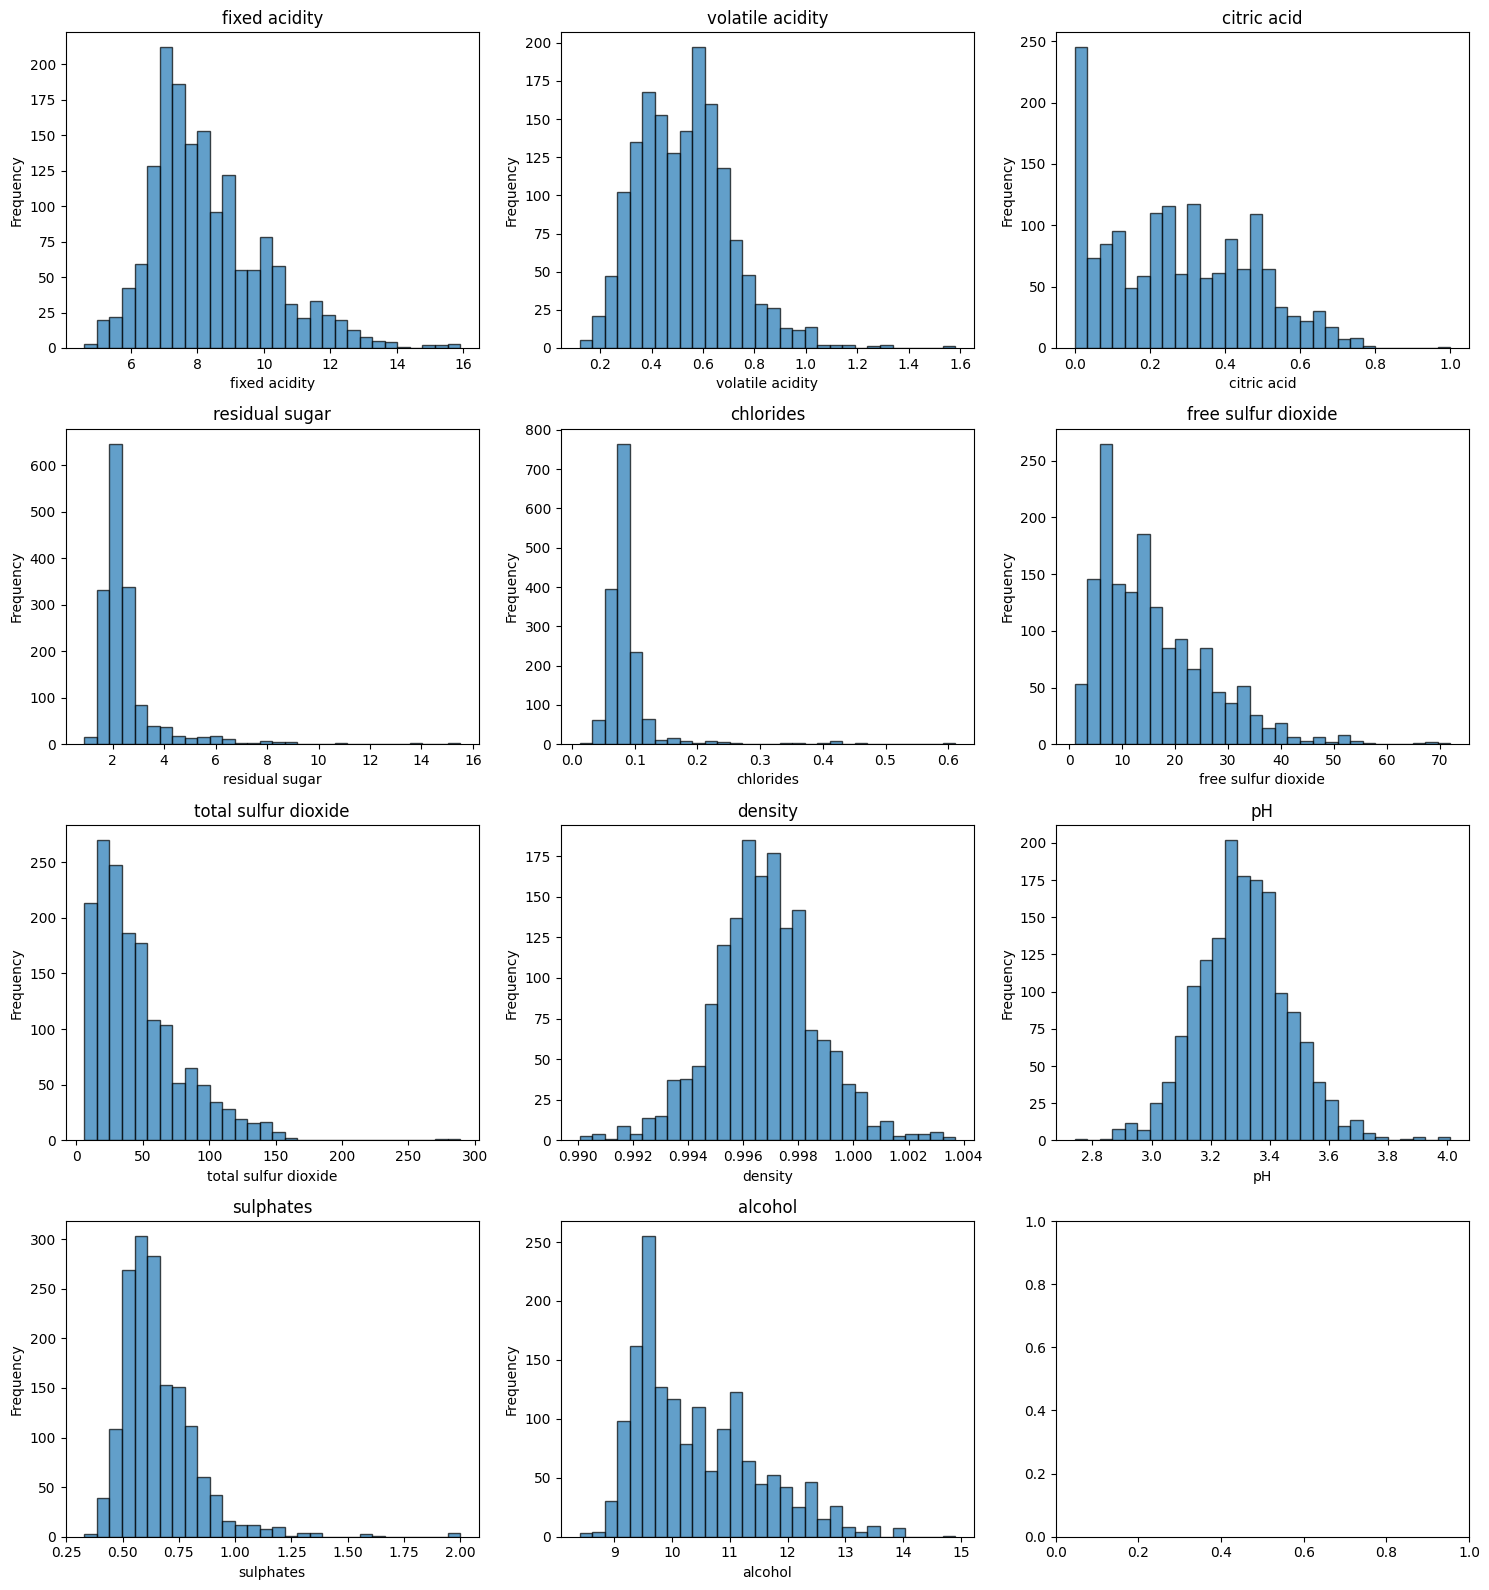

In [15]:

# Step 5: Exploratory Data Analysis - Feature Distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

features = df.columns.tolist()
features.remove('quality')

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


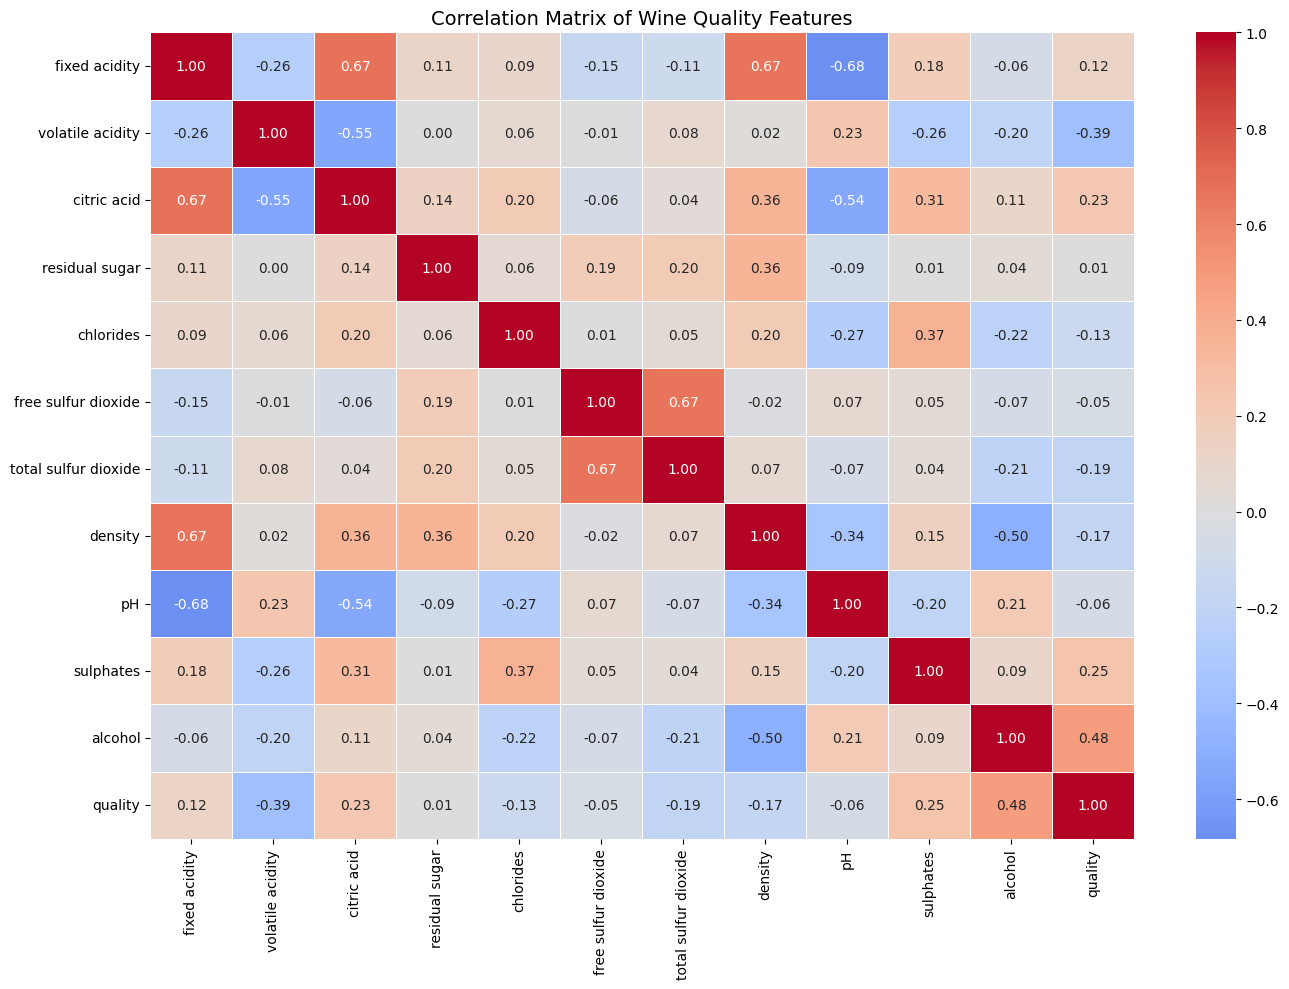


Correlation with Quality (sorted by absolute value):
alcohol                 0.476166
volatile acidity       -0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
fixed acidity           0.124052
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
Name: quality, dtype: float64


In [16]:

# Step 6: Exploratory Data Analysis - Correlation Analysis
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Wine Quality Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with Quality (sorted by absolute value):")
quality_corr = correlation_matrix['quality'].drop('quality').sort_values(key=abs, ascending=False)
print(quality_corr)



---

## 4. Data Preprocessing

Data preprocessing is crucial for building effective models.


In [17]:

# Step 7: Data Preprocessing - Handle Missing Values
print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Check for missing values
print("\nMissing values before handling:")
print(df.isnull().sum().sum())

# Since there are no missing values in this dataset, let's check for outliers
# For demonstration, let's look at the outliers in some features
print("\nOutliers detection using IQR method:")
for col in features[:5]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")


DATA PREPROCESSING

Missing values before handling:
0

Outliers detection using IQR method:
fixed acidity: 49 outliers (3.06%)
volatile acidity: 19 outliers (1.19%)
citric acid: 1 outliers (0.06%)
residual sugar: 155 outliers (9.69%)
chlorides: 112 outliers (7.00%)


In [18]:

# Step 8: Data Preprocessing - Remove Duplicates
print(f"\nDuplicate rows before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicate rows after: {df.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {df.shape}")



Duplicate rows before: 240
Duplicate rows after: 0
Dataset shape after removing duplicates: (1359, 12)



---

## 5. Feature Engineering

Feature engineering involves creating new features or transforming existing ones to improve model performance.


In [19]:

# Step 9: Feature Engineering - Create New Features
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create new features
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']
df['sugar_to_acidity_ratio'] = df['residual sugar'] / (df['total_acidity'] + 1)
df['alcohol_content'] = df['alcohol'] / df['density']

print("New features created:")
print("- total_acidity: sum of fixed and volatile acidity")
print("- sugar_to_acidity_ratio: ratio of sugar to total acidity")
print("- alcohol_content: alcohol normalized by density")

print(f"\nNew dataset shape: {df.shape}")


FEATURE ENGINEERING
New features created:
- total_acidity: sum of fixed and volatile acidity
- sugar_to_acidity_ratio: ratio of sugar to total acidity
- alcohol_content: alcohol normalized by density

New dataset shape: (1359, 15)


In [20]:

# Step 10: Feature Engineering - Feature Selection
# Select features with good correlation with quality
correlation_with_quality = df.corr()['quality'].drop('quality')

# Select features with absolute correlation > 0.1
important_features = correlation_with_quality[abs(correlation_with_quality) > 0.1].index.tolist()
print("\nImportant features (|correlation| > 0.1):")
print(important_features)

# Let's use multiple features for better prediction
X = df[important_features]
y = df['quality']

print(f"\nSelected Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")



Important features (|correlation| > 0.1):
['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol', 'alcohol_content']

Selected Features Shape: (1359, 9)
Target Shape: (1359,)


In [21]:

# Step 11: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set percentage: {X_train.shape[0]/len(X)*100:.1f}%")
print(f"Test set percentage: {X_test.shape[0]/len(X)*100:.1f}%")


TRAIN-TEST SPLIT
Training set size: 1087
Test set size: 272
Training set percentage: 80.0%
Test set percentage: 20.0%


In [22]:

# Step 12: Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling applied using StandardScaler")
print(f"X_train_scaled mean: {X_train_scaled.mean():.6f}")
print(f"X_train_scaled std: {X_train_scaled.std():.6f}")


Feature Scaling applied using StandardScaler
X_train_scaled mean: -0.000000
X_train_scaled std: 1.000000



---

## 6. Cost Function (Loss Function)

### Purpose
Measure how well the model fits the data.

### Cost Function (Mean Squared Error)
$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Where:
- $m$ = number of training examples
- $h_\theta(x)$ = hypothesis/prediction

### Why Squaring?
- Cost function is **convex** (has a global minimum)
- No negative errors
- Errors don't cancel out each other
- Larger errors penalized more



---

## 7. Optimization Objective

We need to **minimize** the cost function:

$$\min_{\theta_0, \theta_1} J(\theta_0, \theta_1)$$

- Best-fit line = line that gives minimum cost
- Coefficients tell how much each predictor contributes to the output



---

## 8. Gradient Descent (Optimization Algorithm)

### Idea
Iteratively update parameters to reach global minimum.

### Update Rule
For each parameter $\theta_j$:
$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

Where:
- $\alpha$ = Learning rate
- Move opposite to the slope of the cost function

### Learning Rate ($\alpha$)
- Small $\alpha$ → slow convergence
- Large $\alpha$ → may overshoot minimum


In [23]:

# Step 13: Gradient Descent Implementation (From Scratch)

def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m = len(X)
    X = X.values if hasattr(X, 'values') else X
    y = y.values if hasattr(y, 'values') else y
    
    n_features = X.shape[1] if len(X.shape) > 1 else 1
    theta = np.zeros(n_features)
    cost_history = []
    
    for epoch in range(epochs):
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        
        y_pred = X.dot(theta)
        error = y_pred - y
        
        if n_features == 1:
            cost = (1 / (2 * m)) * np.sum(error ** 2)
            gradient = (1 / m) * np.sum(error * X.flatten())
            theta[0] = theta[0] - learning_rate * gradient
        else:
            cost = (1 / (2 * m)) * np.sum(error ** 2)
            gradient = (1 / m) * X.T.dot(error)
            theta = theta - learning_rate * gradient
        
        cost_history.append(cost)
    
    return theta, cost_history

# Use single feature for visualization
X_single = df['alcohol']
y_data = df['quality']

theta_0_gd, cost_history = gradient_descent(X_single.values.reshape(-1, 1), y_data.values, learning_rate=0.01, epochs=500)

print("=" * 50)
print("GRADIENT DESCENT RESULTS (From Scratch)")
print("=" * 50)
print(f"Slope (theta): {theta_0_gd[0]:.4f}")
print(f"Final Cost: {cost_history[-1]:.4f}")


GRADIENT DESCENT RESULTS (From Scratch)
Slope (theta): 0.5372
Final Cost: 0.2781


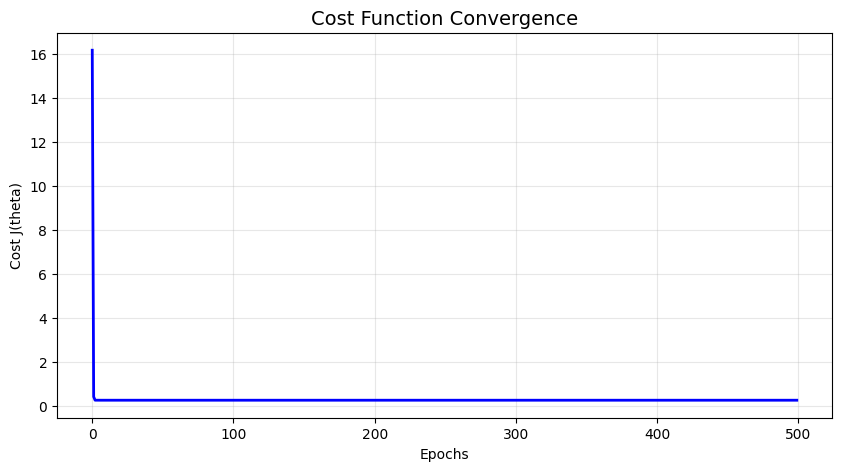

Initial Cost: 16.1494
Final Cost: 0.2781
Cost Reduced by: 98.28%


In [24]:

# Step 14: Visualize Cost Function Convergence
plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='blue', linewidth=2)
plt.title("Cost Function Convergence", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Cost J(theta)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial Cost: {cost_history[0]:.4f}")
print(f"Final Cost: {cost_history[-1]:.4f}")
print(f"Cost Reduced by: {((cost_history[0] - cost_history[-1]) / cost_history[0] * 100):.2f}%")



---

## 9. Linear Regression Using OLS (Ordinary Least Squares)

### Objective
- Find optimal $\beta_0$ and $\beta_1$
- Minimize loss function (MSE)
- Achieves global minimum

### Hypothesis Function
$$h_\theta(x) = \beta_0 + \beta_1 x$$

### Ordinary Least Squares Cost Function
$$S(\beta_0, \beta_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

### Notes on OLS
- Closed-form solution
- Assumes linear relationship
- Errors are normally distributed
- OLS is equivalent to Linear Regression implementation (e.g., sklearn)



---

## 10. Limitations of Linear Regression

1. **Assumes Linearity**: The method assumes the relationship between the variables is linear. If the relationship is non-linear, linear regression might not work well.

2. **Sensitivity to Outliers**: Outliers can significantly affect the slope and intercept, skewing the best-fit line.



---

## 11. Assumptions of Linear Regression

| # | Assumption | Description |
|---|-------------|-------------|
| 1 | **Linearity** | The relationship between inputs (X) and output (Y) is linear (straight line). |
| 2 | **Independence of Errors** | Prediction errors should not be correlated with each other. |
| 3 | **Homoscedasticity** | Errors should have equal variance across all values of X. If variance changes (fans out or shrinks), it's called heteroscedasticity - problematic. |
| 4 | **Normality of Errors** | Errors should follow a normal (bell-shaped) distribution. |
| 5 | **No Multicollinearity** (for multiple regression) | Input variables should not be highly correlated with each other. |
| 6 | **No Autocorrelation** | Errors should not show repeating patterns, especially in time-series data. |



---

## 12. Types of Gradient Descent

### 1. Batch Gradient Descent
- Uses the **entire dataset** to compute the gradient and update weights
- Accurate & stable but computationally expensive
- Slow for very large datasets

### 2. Stochastic Gradient Descent (SGD)
- Uses **random subsets** (mini-batches) or only one training example per update
- Much faster than batch gradient descent
- Introduces noise, but helps escape local minima

### 3. Mini-batch Gradient Descent
- Uses a **small subset** of the dataset
- Balances speed and stability
- Most commonly used in practice



---

## 13. Advanced Optimizers

### Momentum
- Adds a fraction of the previous update to the current one.
- Helps smooth out oscillations.
- Accelerates convergence.

### RMSProp
- Adjusts the learning rate for each parameter based on recent gradients.
- Uses moving averages of squared gradients.

### Adam (Adaptive Moment Estimation)
- Combines Momentum + RMSProp.
- Automatically adapts learning rate during training.
- Most commonly used optimizer in deep learning.



---

## 14. Techniques to Achieve Good Convergence

1. **Learning Rate Scheduling**: Gradually reduce the learning rate as training progresses.
2. **Early Stopping**: Stop training when the model performance stops improving.
3. **Feature Scaling (Normalization)**: Scale input features to a similar range.
4. **Regularization**: Reduces overfitting, controls model complexity by penalizing large weights.



---

## 15. Implementation using Scikit-Learn


In [25]:

# Step 15: Sklearn Implementation
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print("=" * 60)
print("SKLEARN LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"Intercept: {model.intercept_:.4f}")
print("\nCoefficients:")
for feature, coef in zip(important_features, model.coef_):
    print(f"  {feature}: {coef:.4f}")


SKLEARN LINEAR REGRESSION RESULTS
Intercept: 5.6366

Coefficients:
  fixed acidity: 0.0736
  volatile acidity: -0.1911
  citric acid: -0.0221
  chlorides: -0.0935
  total sulfur dioxide: -0.0730
  density: -0.1265
  sulphates: 0.1580
  alcohol: 5.4102
  alcohol_content: -5.1706


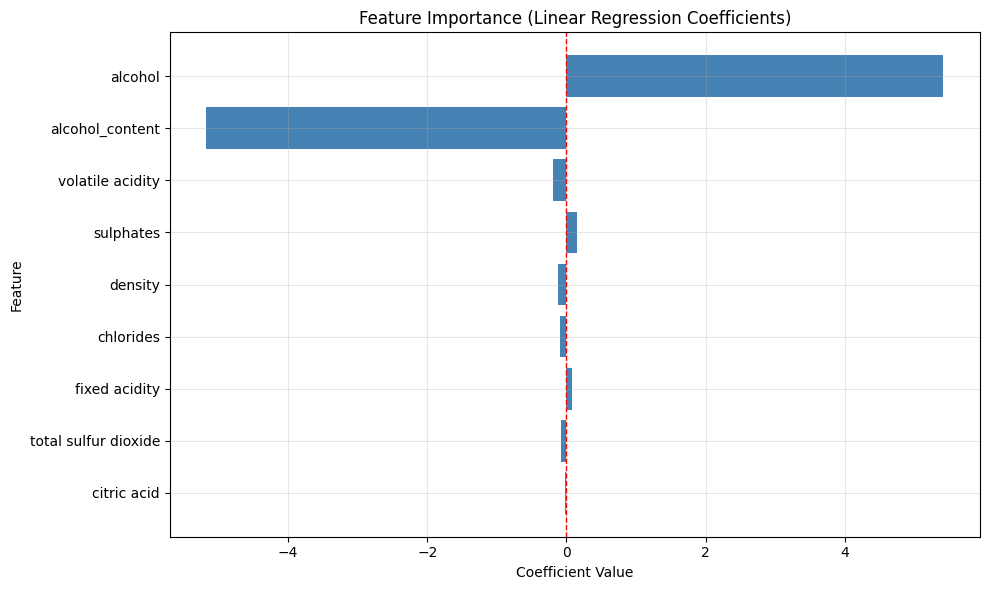

In [26]:

# Step 16: Visualize Feature Importance
plt.figure(figsize=(10, 6))
coef_df = pd.DataFrame({'Feature': important_features, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=True)

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



---

## 16. Evaluation Metrics


In [27]:

# Step 17: Calculate Evaluation Metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 60)
print("EVALUATION METRICS")
print("=" * 60)
print("\nTraining Set:")
print(f"  MAE: {mae_train:.4f}")
print(f"  MSE: {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  R2 Score: {r2_train:.4f}")

print("\nTest Set:")
print(f"  MAE: {mae_test:.4f}")
print(f"  MSE: {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R2 Score: {r2_test:.4f}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("- MAE: Average absolute difference between predicted and actual values")
print("- MSE: Average squared difference (penalizes larger errors more)")
print("- RMSE: Square root of MSE (same units as target variable)")
print("- R2: Proportion of variance explained (1.0 = perfect, 0 = baseline)")


EVALUATION METRICS

Training Set:
  MAE: 0.5136
  MSE: 0.4389
  RMSE: 0.6625
  R2 Score: 0.3441

Test Set:
  MAE: 0.4952
  MSE: 0.4185
  RMSE: 0.6469
  R2 Score: 0.4092

INTERPRETATION
- MAE: Average absolute difference between predicted and actual values
- MSE: Average squared difference (penalizes larger errors more)
- RMSE: Square root of MSE (same units as target variable)
- R2: Proportion of variance explained (1.0 = perfect, 0 = baseline)


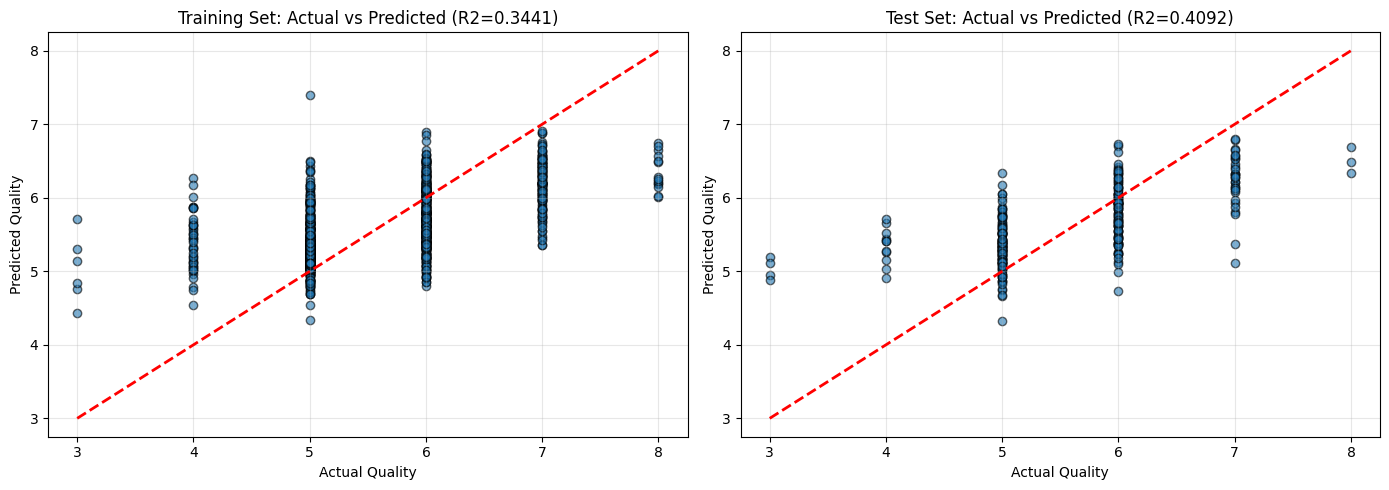

In [28]:

# Step 18: Visualize Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_pred_train, alpha=0.6, edgecolors='black')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Quality')
axes[0].set_ylabel('Predicted Quality')
axes[0].set_title(f'Training Set: Actual vs Predicted (R2={r2_train:.4f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_pred_test, alpha=0.6, edgecolors='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Quality')
axes[1].set_ylabel('Predicted Quality')
axes[1].set_title(f'Test Set: Actual vs Predicted (R2={r2_test:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


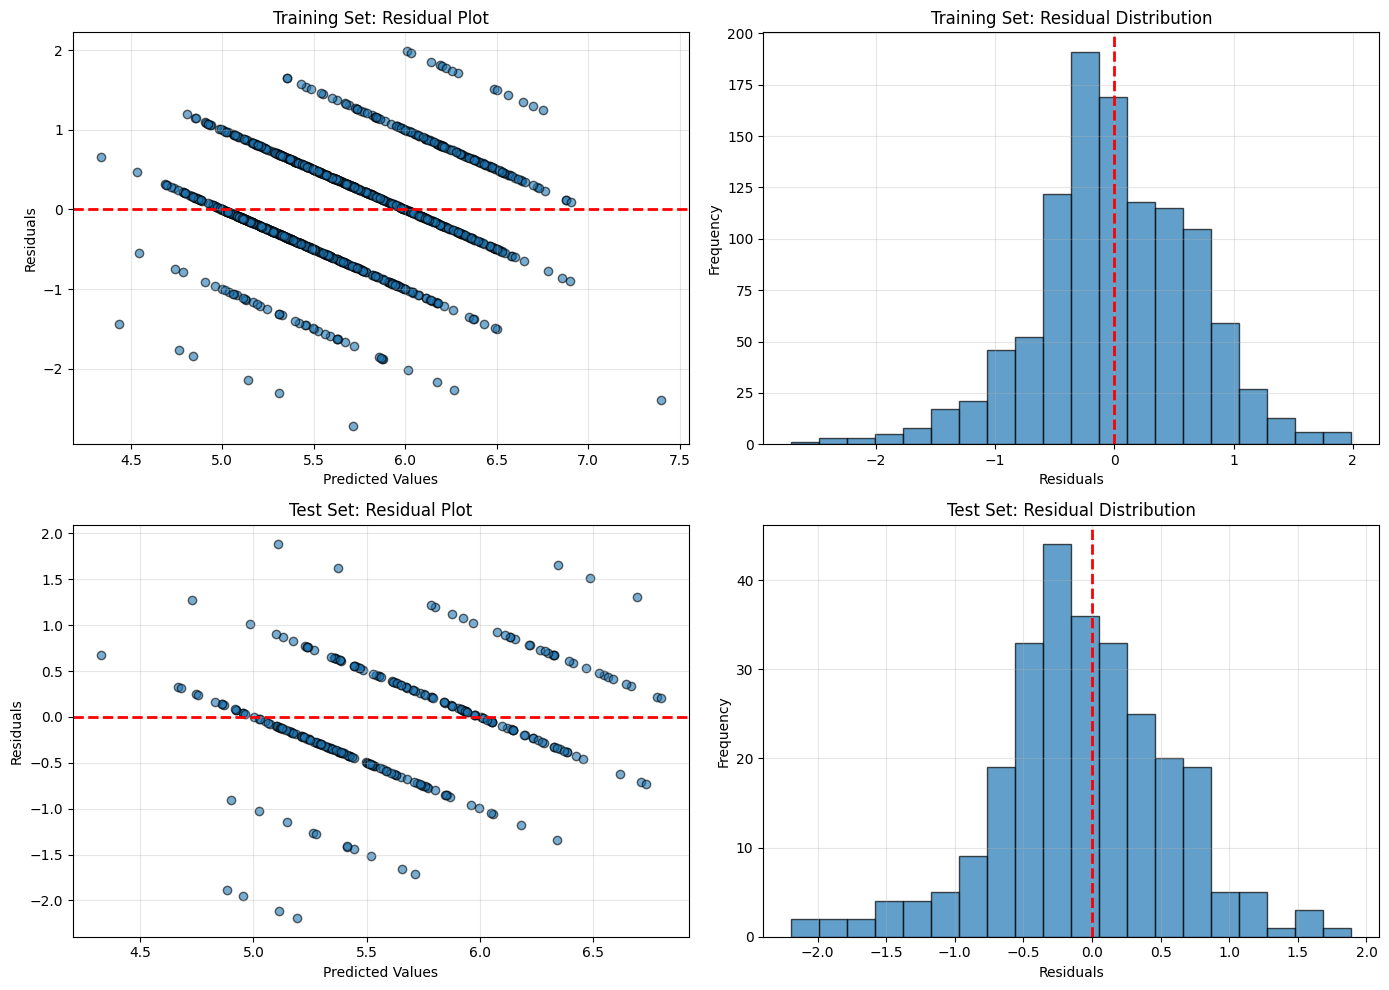

In [29]:

# Step 19: Visualize Residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training residuals
axes[0, 0].scatter(y_pred_train, residuals_train, alpha=0.6, edgecolors='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel("Predicted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Training Set: Residual Plot")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(residuals_train, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel("Residuals")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Training Set: Residual Distribution")
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].grid(True, alpha=0.3)

# Test residuals
axes[1, 0].scatter(y_pred_test, residuals_test, alpha=0.6, edgecolors='black')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel("Predicted Values")
axes[1, 0].set_ylabel("Residuals")
axes[1, 0].set_title("Test Set: Residual Plot")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(residuals_test, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Test Set: Residual Distribution")
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



---

## 17. Hyperparameter Tuning


In [30]:

# Step 20: Experiment with Different Features
from sklearn.linear_model import Ridge, Lasso

# Try with different feature subsets
feature_sets = {
    'All Features': important_features,
    'Top 3 Features': ['alcohol', 'volatile acidity', 'sulphates'],
    'Single Feature (alcohol)': ['alcohol']
}

results = []
for name, features in feature_sets.items():
    X_subset = df[features]
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_subset, y, test_size=0.2, random_state=42)
    
    scaler_sub = StandardScaler()
    X_train_scaled_sub = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled_sub = scaler_sub.transform(X_test_sub)
    
    model_sub = LinearRegression()
    model_sub.fit(X_train_scaled_sub, y_train_sub)
    
    y_pred_sub = model_sub.predict(X_test_scaled_sub)
    r2_sub = r2_score(y_test_sub, y_pred_sub)
    mae_sub = mean_absolute_error(y_test_sub, y_pred_sub)
    
    results.append({'Features': name, 'R2': r2_sub, 'MAE': mae_sub})

results_df = pd.DataFrame(results)
print("=" * 60)
print("FEATURE SELECTION COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))


FEATURE SELECTION COMPARISON
                Features       R2      MAE
            All Features 0.409159 0.495196
          Top 3 Features 0.415140 0.498207
Single Feature (alcohol) 0.242146 0.567469


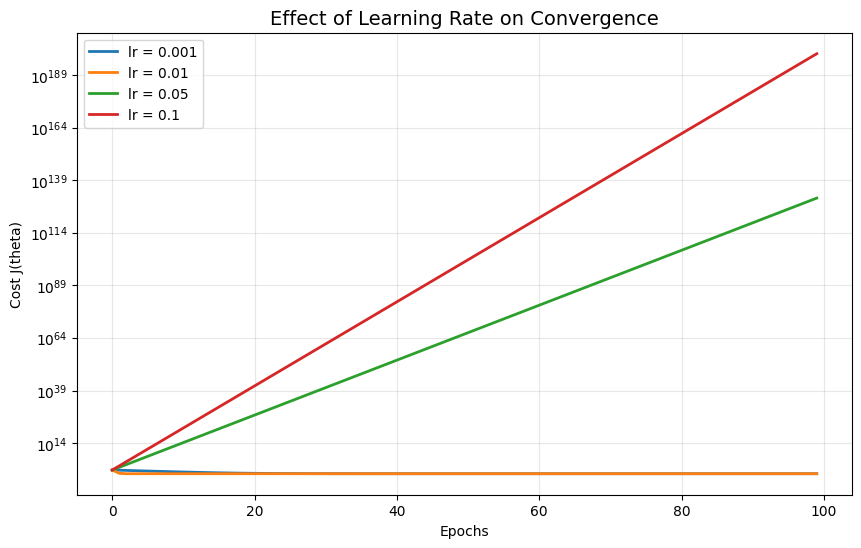

In [31]:

# Step 21: Learning Rate Effect (for Gradient Descent)
# Visualize how different learning rates affect convergence

def gradient_descent_cost(X, y, learning_rate=0.01, epochs=200):
    m = len(X)
    X = X.values.reshape(-1, 1) if hasattr(X, 'values') else X.reshape(-1, 1)
    y = y.values if hasattr(y, 'values') else y
    
    theta = 0
    cost_history = []
    
    for epoch in range(epochs):
        y_pred = theta * X.flatten()
        error = y_pred - y
        cost = (1 / (2 * m)) * np.sum(error ** 2)
        cost_history.append(cost)
        
        gradient = (1 / m) * np.sum(error * X.flatten())
        theta = theta - learning_rate * gradient
    
    return cost_history

plt.figure(figsize=(10, 6))
learning_rates = [0.001, 0.01, 0.05, 0.1]

for lr in learning_rates:
    cost_hist = gradient_descent_cost(df['alcohol'], df['quality'], learning_rate=lr, epochs=100)
    plt.plot(cost_hist, label=f'lr = {lr}', linewidth=2)

plt.title("Effect of Learning Rate on Convergence", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Cost J(theta)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()



---

## 18. Summary

### Key Takeaways:
1. **Linear Regression** finds the best straight line that minimizes the squared error
2. **Gradient Descent** is an iterative optimization algorithm to find optimal parameters
3. **Learning Rate** controls how big steps we take towards the minimum
4. **R2 Score** tells us how well our model explains the variance in the data
5. **Residual Analysis** helps verify the assumptions of linear regression
6. **Feature Engineering** can significantly improve model performance
7. **Data Preprocessing** is crucial for building effective models

### When to Use Linear Regression:
- When relationship between features and target is linear
- When you need interpretable results
- As a baseline model before trying more complex algorithms

### Limitations:
- Assumes linear relationship
- Sensitive to outliers
- Can underfit for complex relationships


In [32]:

# Final Model Summary
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
print(f"Dataset: Wine Quality Dataset")
print(f"Total samples used: {len(df)}")
print(f"Features used: {len(important_features)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Model: Linear Regression")
print(f"Test R2 Score: {r2_test:.4f}")
print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print("=" * 60)


FINAL MODEL SUMMARY
Dataset: Wine Quality Dataset
Total samples used: 1359
Features used: 9
Training samples: 1087
Test samples: 272
Model: Linear Regression
Test R2 Score: 0.4092
Test MAE: 0.4952
Test RMSE: 0.6469
